#  AI Programming Foundations Project: County Level Income and Health Data

**Author:** Zhirui Wang

---

## Table of Contents
1. Setup  
2. Data Ingestion  
3. Data Cleaning  
4. Exploratory Data Analysis  
5. Feature Engineering  
6. Visualizations  
7. Summary and Interpretation  
8. Save Outputs  

---

## Introduction

This notebook presents the complete data workflow for the AI Programming Foundations Project capstone. It follows a clear structure from setup through ingestion, cleaning, exploratory analysis, visualizations, and interpretation.

## Project Description

This project builds a complete, reproducible data workflow to explore how county-level socioeconomic conditions (median household income from the [American Community Survey](https://data.census.gov/)) relate to selected health outcomes and risk factors from [CDC PLACES](https://chronicdata.cdc.gov/places). We load, clean, merge, and visualize two public datasets and document findings for use as a foundation for future ML or AI workflows.

---
## 1. Setup

**Data sources (self-chosen datasets):**
- **CDC PLACES:** [PLACES: Local Data for Better Health, County Data 2024](https://data.census.gov/table/ACSDT5Y2023.B19013). File in repo: `Data/Raw/PLACES__Local_Data_for_Better_Health__County_Data_2024_release.csv`
- **ACS B19013:** [U.S. Census Bureau, American Community Survey 5-Year Estimates, Table B19013](https://catalog.data.gov/dataset/places-local-data-for-better-health-county-data-2024-release). Median household income by county. Folder in repo: `Data/Raw/ACSDT5Y2024.B19013_2026-03-01T180214/`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Project root = directory where notebook is run from (run from repo root)
PROJECT_ROOT = os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.config import RANDOM_SEED, DATA_RAW, DATA_PROCESSED, OUTPUTS_FIGURES, SELECTED_MEASURE_IDS
from src.io import load_places, load_acs_income
from src.cleaning import standardize_county_fips, coerce_numeric, filter_places_measure, pivot_places_wide
from src.eda import run_eda
from src.viz import plot_scatter_income_vs_outcome, plot_box_outcome_by_income_quartile, plot_corr_heatmap

# Reproducibility
np.random.seed(RANDOM_SEED)

# Display options
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = (8, 5)

# Ensure output dirs exist
os.makedirs(DATA_PROCESSED, exist_ok=True)
os.makedirs(OUTPUTS_FIGURES, exist_ok=True)

---
## 2. Data Ingestion

In [2]:
# Load CDC PLACES county data (2024 release)
places_raw = load_places()
places_raw.head()

,Year,StateAbbr,StateDesc,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text,Geolocation
0,2022,AL,Alabama,Clay,BRFSS,Health Outcomes,Current asthma among adults,%,Crude prevalence,11.0,NaN,NaN,9.6,12.4,14198,11235,1027,HLTHOUT,CASTHMA,CrdPrv,Current Asthma,POINT (-85.8606604130173 33.2693085517833)
1,2022,AL,Alabama,Dale,BRFSS,Health Outcomes,Arthritis among adults,%,Crude prevalence,35.6,NaN,NaN,34.8,36.4,49544,38039,1045,HLTHOUT,ARTHRITIS,CrdPrv,Arthritis,POINT (-85.6109266826185 31.4316629601359)
2,2022,AL,Alabama,Jackson,BRFSS,Health Outcomes,Stroke among adults,%,Crude prevalence,5.1,NaN,NaN,4.6,5.6,52891,42087,1071,HLTHOUT,STROKE,CrdPrv,Stroke,POINT (-85.9995052603961 34.7796392771775)
3,2022,AL,Alabama,Lauderdale,BRFSS,Health Outcomes,Obesity among adults,%,Age-adjusted prevalence,36.5,NaN,NaN,29.6,43.9,95878,77472,1077,HLTHOUT,OBESITY,AgeAdjPrv,Obesity,POINT (-87.6540983850983 34.9014438477101)
4,2022,AL,Alabama,Lawrence,BRFSS,Disability,Any disability among adults,%,Crude prevalence,40.1,NaN,NaN,35.5,44.7,33214,26022,1079,DISABLT,DISABILITY,CrdPrv,Any Disability,POINT (-87.3108851040374 34.5216735395968)


In [3]:
# Load ACS B19013 median household income by county
acs_raw = load_acs_income()
acs_raw.head()

,GEO_ID,NAME,B19013_001E,B19013_001M,Unnamed: 4
0,0500000US01001,"Autauga County, Alabama",72481,5640,NaN
1,0500000US01003,"Baldwin County, Alabama",78775,2602,NaN
2,0500000US01005,"Barbour County, Alabama",46042,5089,NaN
3,0500000US01007,"Bibb County, Alabama",52541,8950,NaN
4,0500000US01009,"Blount County, Alabama",64190,3472,NaN


---
## 3. Data Cleaning

We use **at least two cleaning functions** with docstrings:
- **standardize_county_fips**: Ensures a 5-digit county FIPS for joining; drops invalid rows. Necessary because PLACES uses `LocationID` and ACS uses `GEO_ID` (e.g. `0500000US01001`); both must become a single key.
- **coerce_numeric**: Converts value columns to numeric and treats Census/PLACES suppressed values (e.g. `-`, `N`, `(X)`) as missing. Necessary to avoid type errors and biased statistics.
- **filter_places_measure** and **pivot_places_wide**: Reduce PLACES to selected measures and one row per county.

In [4]:
# Clean PLACES: standardize FIPS using cleaning function, then filter and pivot
places_df = standardize_county_fips(places_raw, 'LocationID')
places_df = filter_places_measure(places_df, SELECTED_MEASURE_IDS)
places_df = coerce_numeric(places_df, ['Data_Value'])
places_wide = pivot_places_wide(places_df, value_col='Data_Value', index_col='county_fips')
print('PLACES wide shape:', places_wide.shape)
places_wide.head()

PLACES wide shape: (3145, 6)


MeasureId,county_fips,ARTHRITIS,BPHIGH,DEPRESSION,DIABETES,OBESITY
0,00059,24.95,31.15,20.90,11.20,33.35
1,01001,32.10,38.85,24.05,12.15,38.65
2,01003,31.20,35.55,24.30,11.65,36.80
3,01005,34.45,46.50,23.15,17.45,43.55
4,01007,31.80,40.70,26.25,14.20,41.40


In [5]:
# Clean ACS: extract county FIPS from GEO_ID and keep income estimate
acs_clean = standardize_county_fips(acs_raw, 'GEO_ID')
acs_clean = acs_clean[['county_fips', 'NAME', 'B19013_001E', 'B19013_001M']].copy()
acs_clean = acs_clean.rename(columns={'B19013_001E': 'median_household_income', 'B19013_001M': 'income_moe'})
acs_clean = coerce_numeric(acs_clean, ['median_household_income', 'income_moe'])
acs_clean = acs_clean.dropna(subset=['median_household_income'])
print('ACS shape:', acs_clean.shape)
acs_clean.head()

ACS shape: (3221, 4)


,county_fips,NAME,median_household_income,income_moe
0,01001,"Autauga County, Alabama",72481.0,5640.0
1,01003,"Baldwin County, Alabama",78775.0,2602.0
2,01005,"Barbour County, Alabama",46042.0,5089.0
3,01007,"Bibb County, Alabama",52541.0,8950.0
4,01009,"Blount County, Alabama",64190.0,3472.0


In [6]:
# Merge on county FIPS (inner join: keep only counties in both sources)
merged = places_wide.merge(acs_clean, on='county_fips', how='inner')
print('Merged shape:', merged.shape)
print('Counties in merged:', len(merged))
merged.head()

Merged shape: (3143, 9)
Counties in merged: 3143


,county_fips,ARTHRITIS,BPHIGH,DEPRESSION,DIABETES,OBESITY,NAME,median_household_income,income_moe
0,01001,32.10,38.85,24.05,12.15,38.65,"Autauga County, Alabama",72481.0,5640.0
1,01003,31.20,35.55,24.30,11.65,36.80,"Baldwin County, Alabama",78775.0,2602.0
2,01005,34.45,46.50,23.15,17.45,43.55,"Barbour County, Alabama",46042.0,5089.0
3,01007,31.80,40.70,26.25,14.20,41.40,"Bibb County, Alabama",52541.0,8950.0
4,01009,31.80,37.95,27.40,12.80,37.30,"Blount County, Alabama",64190.0,3472.0


---
## 4. Exploratory Data Analysis

In [7]:
numeric_cols = ['median_household_income'] + [c for c in SELECTED_MEASURE_IDS if c in merged.columns]
eda_results = run_eda(merged, key_id_col='county_fips', numeric_cols=numeric_cols)

print('Shape:', eda_results['shape'])
print('\nMissing counts:')
print(eda_results['missing'][eda_results['missing'] > 0])
print('\nSummary statistics:')
eda_results['summary']

Shape: (3143, 9)

Missing counts:
BPHIGH    67
dtype: int64

Summary statistics:


,median_household_income,OBESITY,DIABETES,BPHIGH,DEPRESSION,ARTHRITIS
count,3143.000000,3143.000000,3143.000000,3076.000000,3143.000000,3143.000000
mean,67976.429208,37.767976,12.317849,35.128674,23.731880,28.676853
std,17774.483025,4.632968,2.421685,4.886830,3.374251,3.600155
min,22188.000000,17.650000,6.400000,22.950000,12.450000,17.300000
25%,56728.000000,35.125000,10.600000,31.750000,21.500000,26.350000
50%,65681.000000,38.300000,12.000000,34.550000,23.700000,28.650000
75%,75827.000000,40.850000,13.850000,38.100000,25.800000,31.100000
max,181765.000000,52.600000,23.600000,54.050000,34.750000,42.200000


In [8]:
print('Top 10 counties by median household income:')
eda_results['top_counties']

Top 10 counties by median household income:


,county_fips,median_household_income,OBESITY,DIABETES,BPHIGH,DEPRESSION,ARTHRITIS
2873,51107,181765.0,29.00,9.95,26.15,19.45,21.45
229,06085,164281.0,22.10,10.35,24.15,16.95,17.30
227,06081,158855.0,21.55,9.60,25.85,17.30,18.30
2849,51059,153637.0,27.10,10.20,26.90,19.00,20.25
1207,24027,149763.0,27.05,9.40,29.20,18.35,21.30
263,08035,149594.0,21.15,6.55,23.50,19.85,20.55
207,06041,149091.0,23.50,8.55,24.85,19.65,22.40
1811,35028,147139.0,22.50,7.05,27.15,18.70,21.70
1858,36059,146202.0,26.95,9.95,26.95,16.30,21.70
446,13117,143784.0,31.75,8.85,27.25,18.85,22.80


In [9]:
print('Bottom 10 counties by median household income:')
eda_results['bottom_counties']

Bottom 10 counties by median household income:


,county_fips,median_household_income,OBESITY,DIABETES,BPHIGH,DEPRESSION,ARTHRITIS
1413,28021,31897.0,50.20,18.90,51.55,18.50,31.70
3016,54047,31559.0,44.50,19.95,45.75,29.55,42.20
1430,28055,31429.0,45.25,16.05,46.90,18.10,29.40
1001,21013,31354.0,44.25,15.85,43.45,29.15,35.55
5,01011,31310.0,49.50,21.15,50.65,21.90,33.95
1113,21237,30417.0,44.90,18.15,45.40,31.80,38.45
31,01063,29200.0,50.70,22.15,54.05,21.95,37.50
2476,47095,28814.0,44.75,16.55,41.65,29.20,33.85
508,13243,28380.0,47.95,20.85,51.65,21.60,36.95
1089,21189,22188.0,41.15,15.35,42.15,29.25,35.30


In [10]:
print('Correlation matrix (numeric columns):')
eda_results['correlation']

Correlation matrix (numeric columns):


,median_household_income,OBESITY,DIABETES,BPHIGH,DEPRESSION,ARTHRITIS
median_household_income,1.000000,-0.610129,-0.667999,-0.695342,-0.296881,-0.634008
OBESITY,-0.610129,1.000000,0.715978,0.711720,0.185311,0.521812
DIABETES,-0.667999,0.715978,1.000000,0.843804,0.229515,0.555386
BPHIGH,-0.695342,0.711720,0.843804,1.000000,0.274431,0.737723
DEPRESSION,-0.296881,0.185311,0.229515,0.274431,1.000000,0.528049
ARTHRITIS,-0.634008,0.521812,0.555386,0.737723,0.528049,1.000000


---
## 5. Feature Engineering

In [11]:
merged['log_income'] = np.log1p(merged['median_household_income'])
merged['income_quartile'] = pd.qcut(merged['median_household_income'].rank(method='first'), 4,
                                     labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])
merged[['county_fips', 'median_household_income', 'log_income', 'income_quartile']].head(10)

,county_fips,median_household_income,log_income,income_quartile
0,01001,72481.0,11.191094,Q3
1,01003,78775.0,11.274364,Q4 (high)
2,01005,46042.0,10.737331,Q1 (low)
3,01007,52541.0,10.869368,Q1 (low)
4,01009,64190.0,11.069618,Q2
5,01011,31310.0,10.351725,Q1 (low)
6,01013,44755.0,10.708981,Q1 (low)
7,01015,55029.0,10.915634,Q1 (low)
8,01017,49656.0,10.812895,Q1 (low)
9,01019,53863.0,10.894218,Q1 (low)


---
## 6. Visualizations

At least **three visualizations** with title, axis labels, and interpretation.

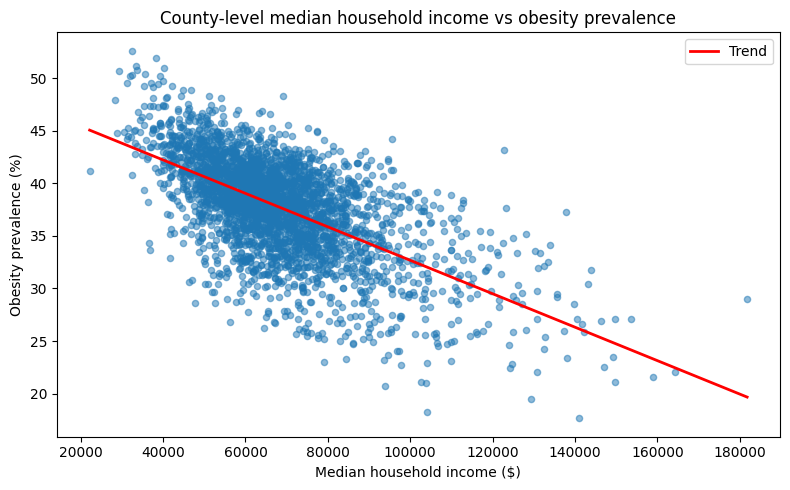

In [12]:
# Visualization 1: Scatter — median income vs obesity prevalence + trend line
fig, ax = plt.subplots(figsize=(8, 5))
plot_scatter_income_vs_outcome(
    merged, income_col='median_household_income', outcome_col='OBESITY',
    title='County-level median household income vs obesity prevalence',
    xlabel='Median household income ($)', ylabel='Obesity prevalence (%)',
    ax=ax, add_trend=True
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_FIGURES, 'scatter_income_vs_obesity.png'), dpi=150)
plt.show()

**Interpretation:** The scatter plot shows that as median household income increases, obesity prevalence tends to decrease (negative trend). There is substantial variation around the trend; some higher-income counties still have relatively high obesity. Outliers may reflect regional or demographic differences not captured by income alone.

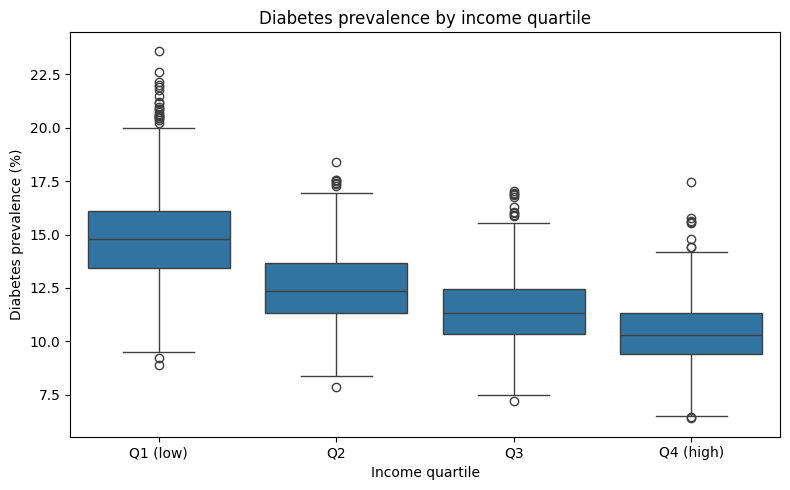

In [13]:
# Visualization 2: Boxplot — diabetes prevalence by income quartile
fig, ax = plt.subplots(figsize=(8, 5))
plot_box_outcome_by_income_quartile(
    merged, income_col='median_household_income', outcome_col='DIABETES',
    quartile_col='income_quartile',
    title='Diabetes prevalence by income quartile',
    xlabel='Income quartile', ylabel='Diabetes prevalence (%)',
    ax=ax
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_FIGURES, 'box_diabetes_by_income_quartile.png'), dpi=150)
plt.show()

**Interpretation:** Diabetes prevalence is generally higher in lower-income quartiles (Q1) and lower in the highest-income quartile (Q4). The boxplot shows both central tendency and spread: Q1 has a higher median and often a wider range, consistent with an inverse association between county income and diabetes prevalence.

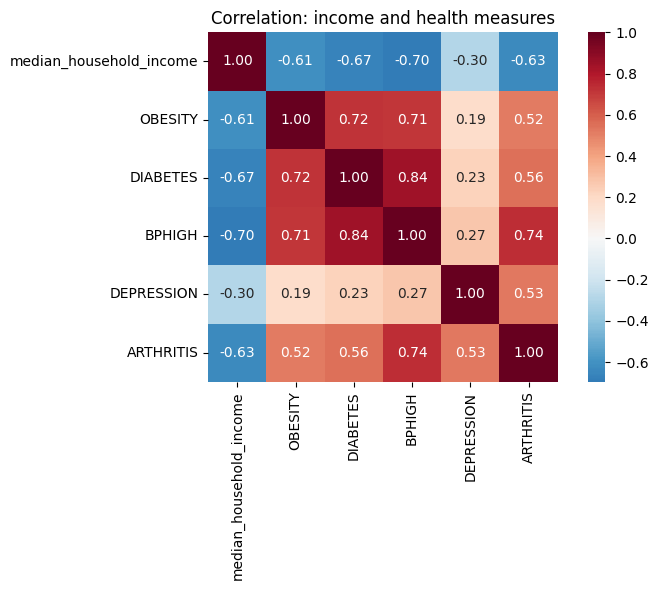

In [14]:
# Visualization 3: Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
plot_corr_heatmap(eda_results['correlation'], title='Correlation: income and health measures', ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_FIGURES, 'correlation_heatmap.png'), dpi=150)
plt.show()

**Interpretation:** Median household income is negatively correlated with most health outcome prevalences (obesity, diabetes, high blood pressure, depression, arthritis), meaning higher-income counties tend to have lower prevalence. Health outcomes are positively correlated with each other, suggesting they often co-occur at the county level.

---
## 7. Summary and Interpretation

- **What we did:** We merged CDC PLACES county health estimates (2024) with ACS 5-year median household income (B19013) on county FIPS. We cleaned and standardized FIPS, coerced numeric values, filtered to five health measures (obesity, diabetes, high blood pressure, depression, arthritis), and pivoted PLACES to one row per county.

- **Findings:** (1) Scatter and trend line show a negative association between county median income and obesity. (2) Boxplots show diabetes prevalence is higher in lower-income quartiles. (3) Correlation heatmap confirms income is negatively related to the selected health outcomes and that health outcomes are positively correlated with each other.

- **Limitations:** (1) **Ecological fallacy**: County-level associations do not imply the same relationship at the individual level. (2) PLACES estimates are model-based (BRFSS); ACS has margins of error. (3) Confounders (e.g., age, race, access to care) are not adjusted for. (4) Dropping counties with missing or suppressed data may introduce selection bias.

- **Problems encountered:** The PLACES CSV triggered a pandas DtypeWarning for mixed types in some columns; we used `low_memory=False` when loading to avoid this. The ACS export included a duplicate header row (e.g. "Geography"); we dropped that row in the loader so the first data row is valid.

- **Assumptions:** Inner join keeps only counties present in both datasets; we assumed 5-digit FIPS is the correct join key and that age-adjusted or crude prevalences are acceptable for comparison.

---
## 8. Save Outputs

In [ ]:
merged.to_csv(os.path.join(DATA_PROCESSED, 'merged_county_places_acs.csv'), index=False)
print('Saved merged dataset to', os.path.join(DATA_PROCESSED, 'merged_county_places_acs.csv'))
print('Figures saved to', OUTPUTS_FIGURES)